# Edge Transformer (exists-only) — Training + Multi-N Inference
Feature = `[edge_exists]` only. No degree, no common neighbours — transformer earns it all.

Checkpoints saved to `./checkpoints_exists_{checker_name}_n{N}/`.

In [13]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from turan_env_c import (
    CEnv,
    CHECKER_C3, CHECKER_C4, CHECKER_C3C4,
    CHECKER_K23, CHECKER_THETA123, CHECKER_BULL,
    CHECKER_BOWTIE, CHECKER_K4,
)
from edge_transformer_policy_exists import EdgeTransformerPolicyExists
from ppo_edge_exists import CFG, train, load_checkpoint, train_multi_n_random
from ppo3 import run_episodes
from torch.optim import Adam

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")

import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

torch 2.10.0+cu130  cuda=True
  NVIDIA GeForce RTX 5090


## Pick your setup
Edit the cell below, then run all.

In [ ]:
# ── CHANGE THESE ──────────────────────────────────────────────────────────────
CHECKER = CHECKER_C3   # CHECKER_C3 | CHECKER_C4 | CHECKER_K4 | ...
N       = 20           # graph size for single-n training
RESUME  = None         # e.g. './checkpoints_exists_c3_n20/best.pt'
TRAIN   = True         # set False to skip training and load RESUME for eval only

# Policy architecture
D_MODEL  = 64
N_HEADS  = 4
N_LAYERS = 4
# ──────────────────────────────────────────────────────────────────────────────

CHECKER_NAMES = {
    CHECKER_C3:       'c3',
    CHECKER_C4:       'c4',
    CHECKER_C3C4:     'c3c4',
    CHECKER_K23:      'k23',
    CHECKER_THETA123: 'theta123',
    CHECKER_BULL:     'bull',
    CHECKER_BOWTIE:   'bowtie',
    CHECKER_K4:       'k4',
}

KNOWN_BOUNDS = {
    CHECKER_C3: N**2 // 4,
    CHECKER_C4: None,
    CHECKER_K4: N**2 // 3,
}

checker_name = CHECKER_NAMES[CHECKER]
ckpt_dir     = f'./checkpoints_exists_{checker_name}_n{N}'
bound        = KNOWN_BOUNDS.get(CHECKER)

print(f"Checker  : {checker_name}  (id={CHECKER})")
print(f"N        : {N}")
print(f"Bound    : {bound if bound else 'unknown'}")
print(f"Ckpt dir : {ckpt_dir}")
print(f"Train    : {TRAIN}  |  Resume: {RESUME}")
print(f"Policy   : d={D_MODEL}  heads={N_HEADS}  layers={N_LAYERS}")

Checker  : c3  (id=0)
N        : 20
Bound    : 100
Ckpt dir : ./checkpoints_exists_c3_n20
Train    : True  |  Resume: None
Policy   : d=64  heads=4  layers=4


In [ ]:
cfg = {**CFG}   # copy defaults

cfg['n']              = N
cfg['checker_id']     = CHECKER
cfg['checkpoint_dir'] = ckpt_dir

# Policy architecture (stored in cfg so checkpoints are self-describing)
cfg['d_model']  = D_MODEL
cfg['n_heads']  = N_HEADS
cfg['n_layers'] = N_LAYERS

# ── hyperparams (edit freely, these override the checkpoint when resuming) ──
cfg['total_steps'] = 5_000_000
cfg['lr']          = 3e-4
cfg['ent_coef']    = 0.02
cfg['num_envs']    = 1024

for k, v in cfg.items():
    print(f"  {k:20s} = {v}")

  n                    = 20
  num_envs             = 1024
  checker_id           = 0
  n_steps              = 64
  n_epochs             = 10
  batch_size           = 2048
  lr                   = 0.0001
  gamma                = 0.99
  gae_lambda           = 0.95
  clip_eps             = 0.2
  vf_coef              = 0.5
  ent_coef             = 0.02
  max_grad_norm        = 0.5
  total_steps          = 3000000
  device               = cuda
  log_interval         = 10
  save_interval        = 100
  checkpoint_dir       = ./checkpoints_exists_c3_n20
  d_model              = 64
  n_heads              = 4
  n_layers             = 4


## Env sanity + benchmark

In [16]:
env = CEnv(n=N, num_envs=cfg['num_envs'], checker_id=CHECKER)
obs = env.reset()
print(f"obs shape  : {obs.shape}   dtype: {obs.dtype}")
print(f"num_actions: {env.num_actions}  (= {N}*{N-1}/2)")
env.benchmark(steps=200)
env.close()

p = EdgeTransformerPolicyExists(D_MODEL, N_HEADS, N_LAYERS)
print(f"\nPolicy params: {sum(x.numel() for x in p.parameters()):,}")
del p

obs shape  : (1024, 190)   dtype: bool
num_actions: 190  (= 20*19/2)
200 steps x 1024 envs in 0.08s
  2,716,563 steps/sec
  2.72M steps/sec

Policy params: 137,283


## Train

In [17]:
if TRAIN:
    policy, history = train(cfg=cfg, resume=RESUME)
else:
    assert RESUME and os.path.exists(RESUME), \
        f"Set RESUME to a valid checkpoint path when TRAIN=False (got: {RESUME})"
    policy, _, cfg, _, _, _ = load_checkpoint(RESUME)
    policy.eval()
    history = []
    print(f"Loaded checkpoint: {RESUME} (training skipped)")


PPO (exists-only)  n=20  envs=1024  checker=0  device=cuda
transitions/update: 65,536   total iters: 45
params: 137,283

200 steps x 1024 envs in 0.04s
  4,569,698 steps/sec
  4.57M steps/sec
iter    10 | steps 0.66M | fps  5,371 | ret 26.95 | best 26.95 | pg -0.0032 | vf 37.174 | ent 5.068 | clip 0.078 | t 125s
iter    20 | steps 1.31M | fps  5,374 | ret 35.55 | best 35.55 | pg 0.1082 | vf 17.020 | ent 3.438 | clip 0.245 | t 247s
iter    30 | steps 1.97M | fps  5,373 | ret 35.80 | best 36.07 | pg 0.0594 | vf 13.827 | ent 3.287 | clip 0.150 | t 369s
iter    40 | steps 2.62M | fps  5,389 | ret 35.76 | best 36.16 | pg 0.0620 | vf 14.380 | ent 3.345 | clip 0.177 | t 491s

done. best return: 36.16


## Training curves

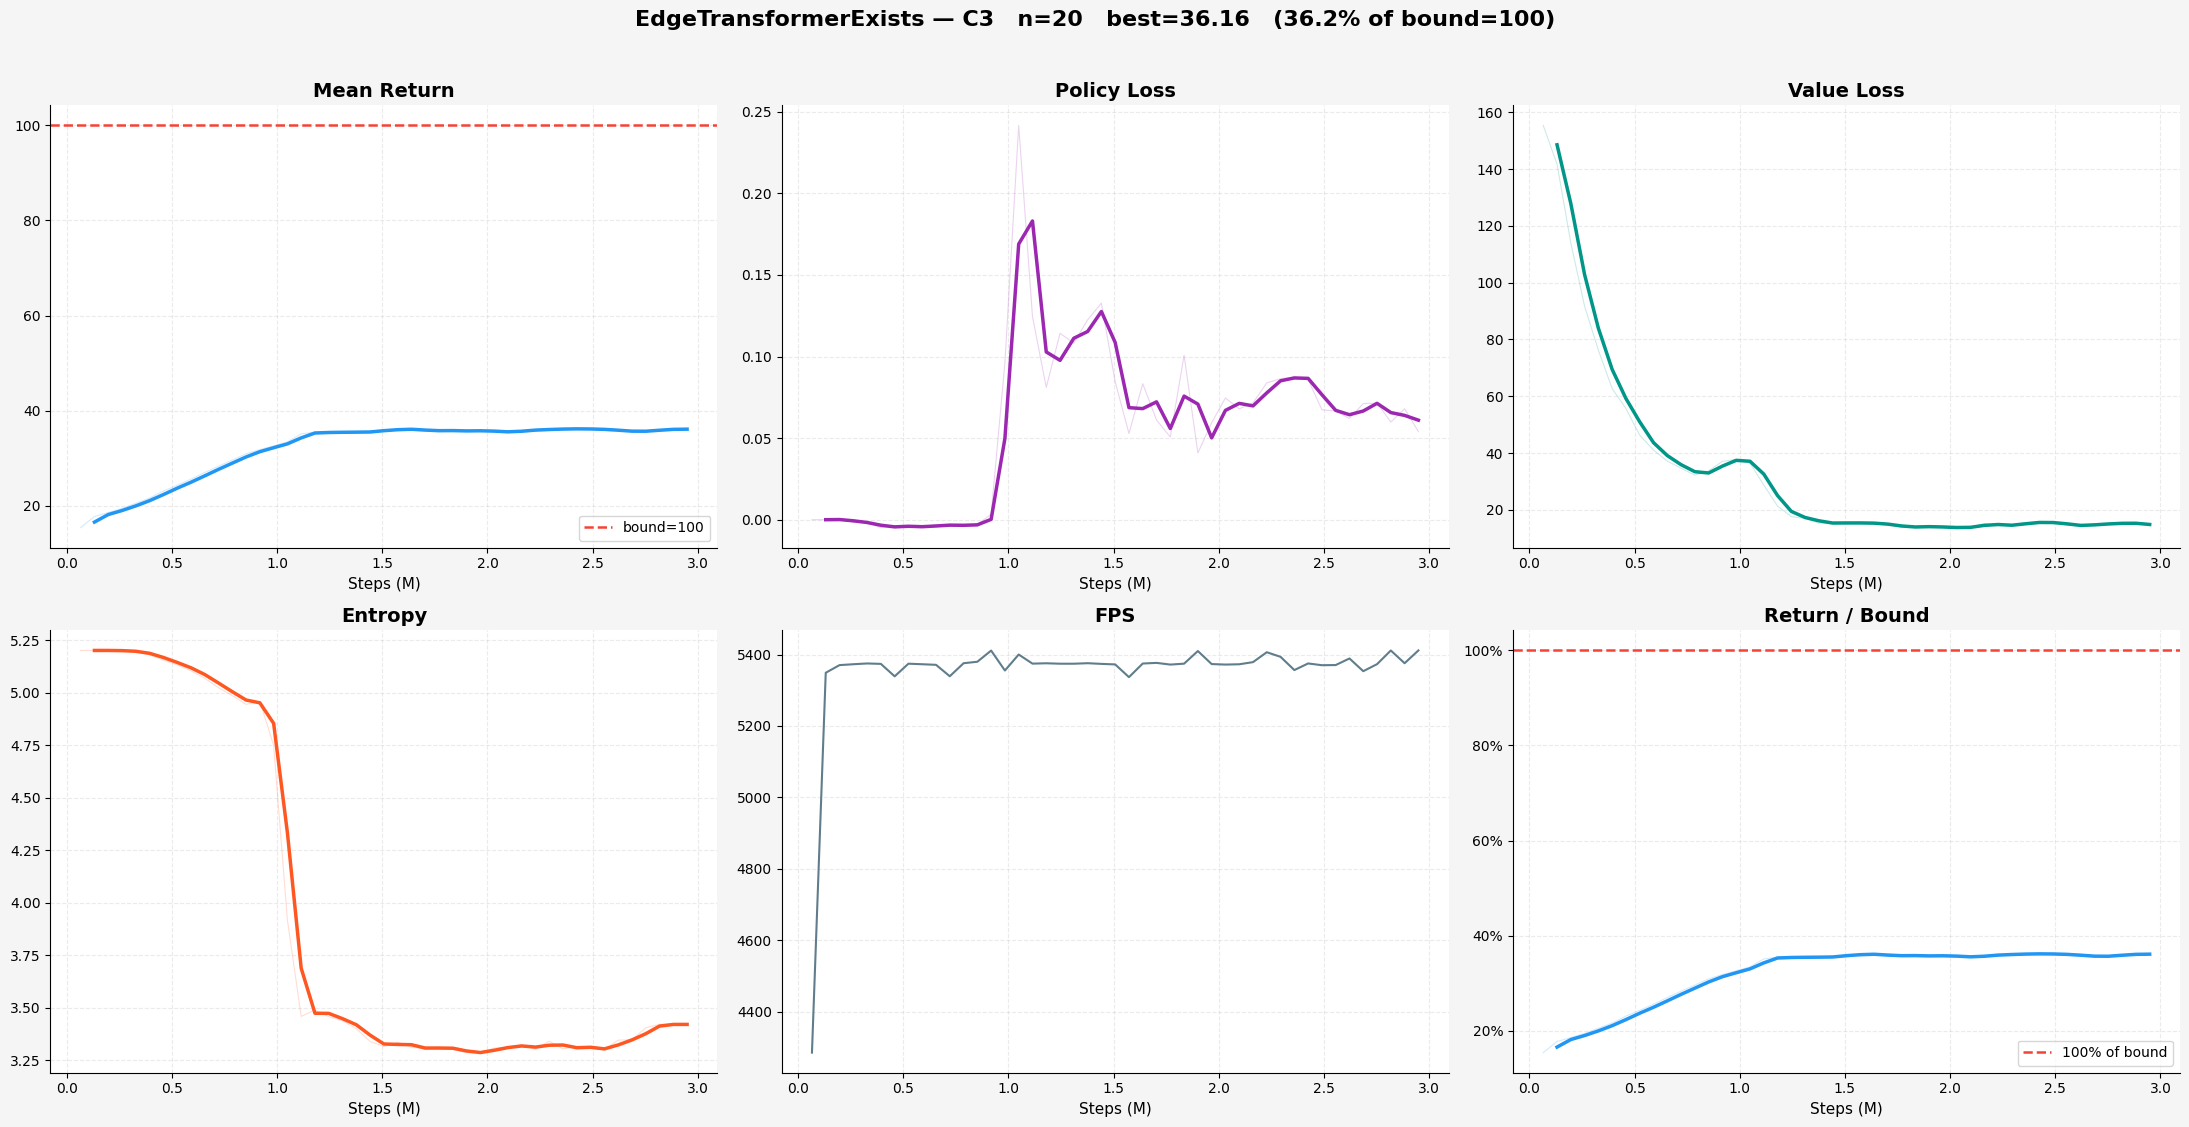

In [18]:
if not history:
    print("No training history — run training or load a checkpoint with TRAIN=True.")
else:
    steps = [h['global_step'] / 1e6 for h in history]
    rets  = [h['mean_ret'] for h in history]
    pg    = [h['pg']       for h in history]
    vf    = [h['vf']       for h in history]
    ent   = [h['ent']      for h in history]
    fps_h = [h['fps']      for h in history]

    def smooth(vals, frac=0.05):
        w = max(1, int(len(vals) * frac))
        return np.convolve(vals, np.ones(w) / w, mode='valid'), w

    COLORS = dict(ret='#2196F3', pg='#9C27B0', vf='#009688',
                  ent='#FF5722', fps='#607D8B', bound='#F44336')

    fig, axes = plt.subplots(2, 3, figsize=(22, 11))
    fig.patch.set_facecolor('#f5f5f5')

    for ax in axes.flat:
        ax.set_facecolor('#ffffff')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
        ax.tick_params(labelsize=10)

    def plot_with_smooth(ax, xs, ys, color, label=None):
        ax.plot(xs, ys, color=color, alpha=0.2, linewidth=0.8)
        sm, w = smooth(ys)
        ax.plot(xs[w-1:], sm, color=color, linewidth=2.5, label=label)

    plot_with_smooth(axes[0,0], steps, rets, COLORS['ret'])
    if bound:
        axes[0,0].axhline(bound, color=COLORS['bound'], linestyle='--', linewidth=1.8, label=f'bound={bound}')
        axes[0,0].legend(fontsize=10)
    axes[0,0].set_title('Mean Return', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Steps (M)', fontsize=11)

    plot_with_smooth(axes[0,1], steps, pg, COLORS['pg'])
    axes[0,1].set_title('Policy Loss', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Steps (M)', fontsize=11)

    plot_with_smooth(axes[0,2], steps, vf, COLORS['vf'])
    axes[0,2].set_title('Value Loss', fontsize=14, fontweight='bold')
    axes[0,2].set_xlabel('Steps (M)', fontsize=11)

    plot_with_smooth(axes[1,0], steps, ent, COLORS['ent'])
    axes[1,0].set_title('Entropy', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Steps (M)', fontsize=11)

    axes[1,1].plot(steps, fps_h, color=COLORS['fps'], linewidth=1.5)
    axes[1,1].set_title('FPS', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Steps (M)', fontsize=11)
    axes[1,1].set_facecolor('#ffffff')
    axes[1,1].spines[['top', 'right']].set_visible(False)
    axes[1,1].grid(True, alpha=0.25, linestyle='--', linewidth=0.8)

    ax = axes[1,2]
    if bound:
        ratio = [r / bound for r in rets]
        plot_with_smooth(ax, steps, ratio, COLORS['ret'])
        ax.axhline(1.0, color=COLORS['bound'], linestyle='--', linewidth=1.8, label='100% of bound')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax.legend(fontsize=10)
        ax.set_title('Return / Bound', fontsize=14, fontweight='bold')
    else:
        plot_with_smooth(ax, steps, rets, COLORS['ret'])
        ax.set_title('Return (smoothed)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Steps (M)', fontsize=11)

    best_ret = max(rets)
    pct_str = f'   ({best_ret/bound*100:.1f}% of bound={bound})' if bound else ''
    fig.suptitle(
        f'EdgeTransformerExists — {checker_name.upper()}   n={N}   best={best_ret:.2f}{pct_str}',
        fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Evaluate — draw the densest graph found (single N)

Edge counts : [24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]
Best found  : 24  (24.0% of bound=100)

  VALID : all 24 edges pass C3 constraint


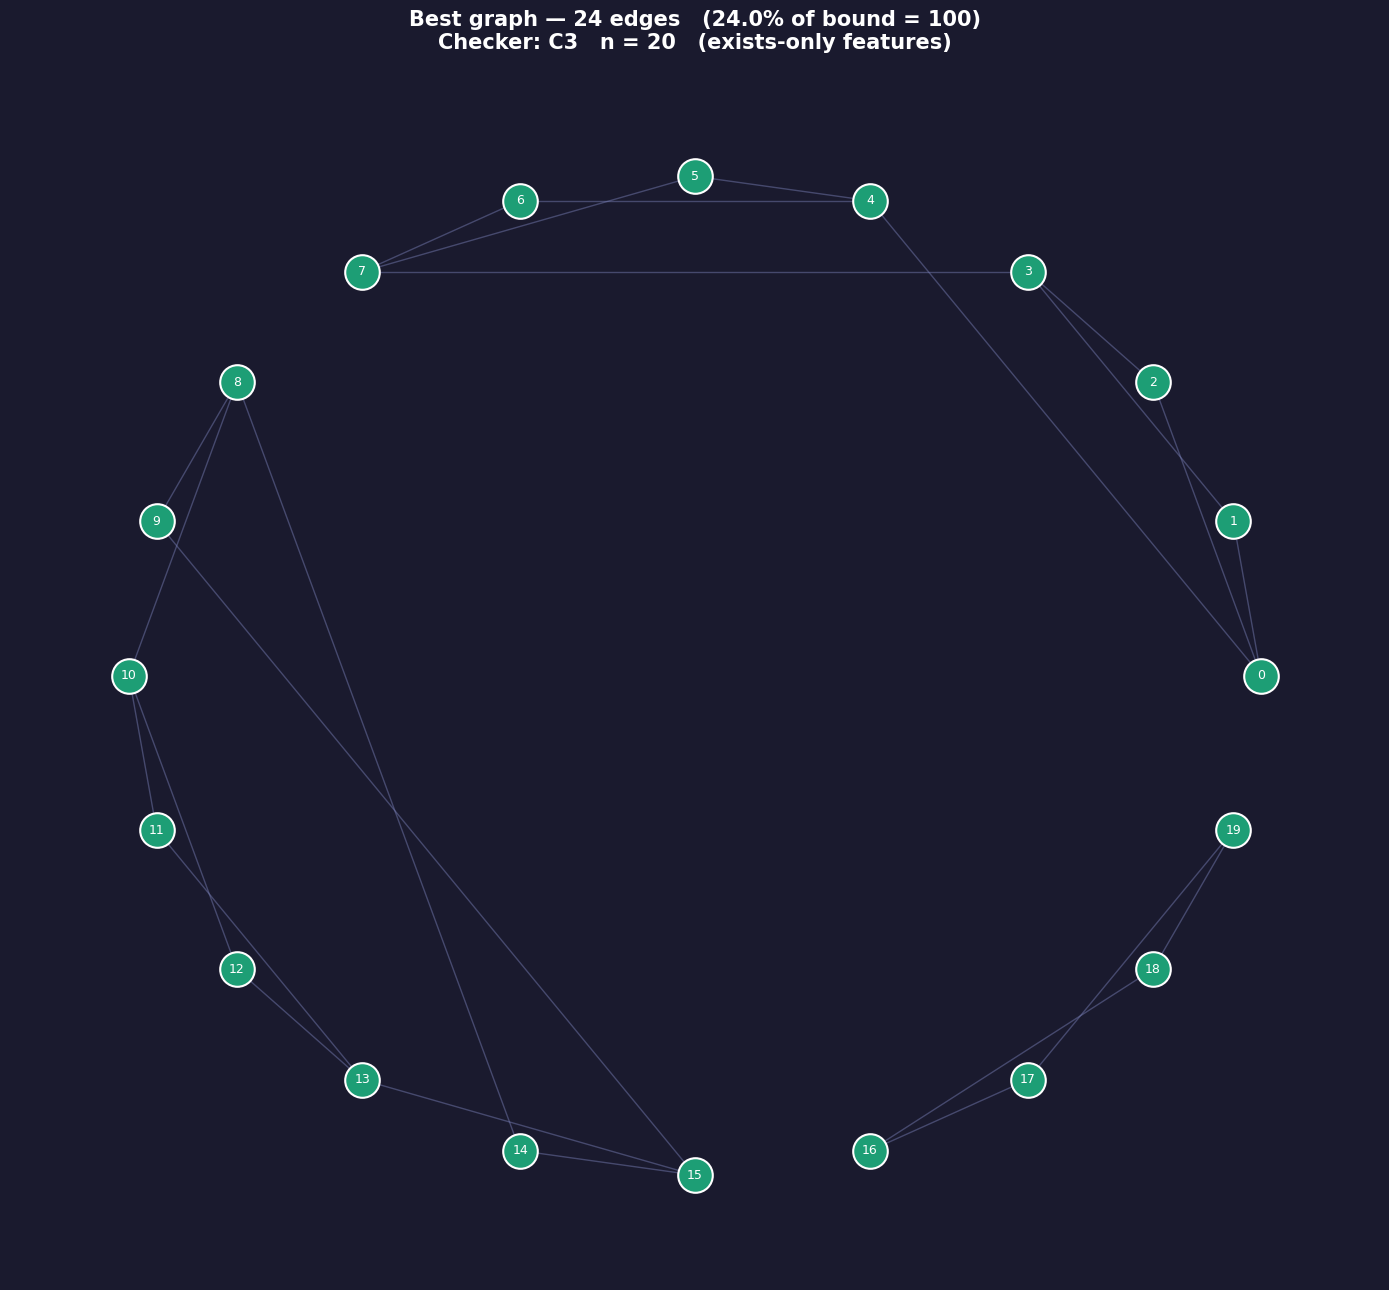

In [19]:
import networkx as nx
from checkers import (
    C3Checker, C4Checker, C3C4Checker,
    K23Checker, Theta123Checker, BullChecker, BowTieChecker,
)

CHECKER_CLASS_MAP = {
    CHECKER_C3:       C3Checker,
    CHECKER_C4:       C4Checker,
    CHECKER_C3C4:     C3C4Checker,
    CHECKER_K23:      K23Checker,
    CHECKER_THETA123: Theta123Checker,
    CHECKER_BULL:     BullChecker,
    CHECKER_BOWTIE:   BowTieChecker,
}

policy.eval()
adjs = run_episodes(policy, cfg, n_episodes=16, deterministic=True)

edge_counts = [int(adj.sum()) // 2 for adj in adjs]
best_adj    = adjs[np.argmax(edge_counts)].copy()
best_edges  = max(edge_counts)
n_graph     = best_adj.shape[0]

print(f"Edge counts : {sorted(edge_counts, reverse=True)}")
print(f"Best found  : {best_edges}" +
      (f"  ({best_edges/bound*100:.1f}% of bound={bound})" if bound else ''))

# ── Checker verification ──────────────────────────────────────────────────────
if CHECKER in CHECKER_CLASS_MAP:
    checker    = CHECKER_CLASS_MAP[CHECKER](n_graph)
    violations = []
    for u in range(n_graph):
        for v in range(u + 1, n_graph):
            if best_adj[u][v]:
                best_adj[u][v] = best_adj[v][u] = 0
                bad = checker.check(best_adj.astype(bool), u, v)
                best_adj[u][v] = best_adj[v][u] = 1
                if bad:
                    violations.append((u, v))
    if violations:
        print(f"\n  INVALID: {len(violations)} edge(s) violate {checker_name.upper()} — "
              f"{violations[:5]}{'...' if len(violations) > 5 else ''}")
    else:
        print(f"\n  VALID : all {best_edges} edges pass {checker_name.upper()} constraint")
else:
    print(f"\n(No Python checker registered for '{checker_name}' — skipping verification)")

# ── Graph layout ──────────────────────────────────────────────────────────────
G = nx.from_numpy_array(best_adj)
if n_graph <= 20:
    pos = nx.circular_layout(G)
elif n_graph <= 60:
    pos = nx.kamada_kawai_layout(G)
else:
    pos = nx.spring_layout(G, seed=42, k=2.5 / n_graph**0.5, iterations=60)

fig, ax = plt.subplots(figsize=(14, 13))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#7c83bc', alpha=0.45, width=1.0)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#1D9E75',
    node_size=max(80, 900 - n_graph * 14), linewidths=1.5, edgecolors='#ffffff')

if n_graph <= 40:
    nx.draw_networkx_labels(G, pos, ax=ax,
        font_color='white', font_size=max(6, 11 - n_graph // 8))

pct_str = f'   ({best_edges / bound * 100:.1f}% of bound = {bound})' if bound else ''
ax.set_title(
    f"Best graph — {best_edges} edges{pct_str}\n"
    f"Checker: {checker_name.upper()}   n = {N}   (exists-only features)",
    fontsize=15, fontweight='bold', color='white', pad=16)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Multi-N Inference
Run the trained policy on a sweep of held-out sizes to test generalisation.
The policy is fully size-agnostic (`proj_in = Linear(1, d)`).

In [20]:
# ── CHANGE THESE ──────────────────────────────────────────────────────────────
EVAL_NS          = [7, 10, 13, 15, 20, 24, 25, 30, 35, 40]  # sizes to probe
N_EVAL_EPISODES  = 32
# ──────────────────────────────────────────────────────────────────────────────

def mantel_bound(n):
    return n * n // 4

print(f"Probing sizes: {EVAL_NS}")
print(f"Episodes per size: {N_EVAL_EPISODES}")

Probing sizes: [7, 10, 13, 15, 20, 24, 25, 30, 35, 40]
Episodes per size: 32


In [21]:
policy.eval()
results = {}

print(f"{'n':>4}  {'best_edges':>10}  {'bound':>6}  {'%bound':>7}")
print('-' * 36)
for n in EVAL_NS:
    adjs  = run_episodes(policy, {**cfg, 'n': n}, n_episodes=N_EVAL_EPISODES, deterministic=True)
    edges = [int(adj.sum()) // 2 for adj in adjs]
    best  = max(edges)
    bd    = mantel_bound(n)
    pct   = best / bd * 100
    results[n] = dict(best=best, bound=bd, pct=pct, adjs=adjs, edges=edges)
    marker = '  <- train N' if n == N else ''
    print(f"{n:>4}  {best:>10}  {bd:>6}  {pct:>6.1f}%{marker}")

   n  best_edges   bound   %bound
------------------------------------
   7          10      12    83.3%
  10          10      25    40.0%


W0319 17:41:45.811000 10754 .venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1676] [0/8] torch._dynamo hit config.recompile_limit (8)
W0319 17:41:45.811000 10754 .venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1676] [0/8]    function: 'forward' (/root/backtoRL/NaiveTrainingV2/edge_transformer_policy_exists.py:88)
W0319 17:41:45.811000 10754 .venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1676] [0/8]    last reason: 0/7: len(self.__class__._cache) == 3                          # cls._cache[key] = (ui, vi, share.float())  # NaiveTrainingV2/edge_transformer_policy_exists.py:80 in _get_cache
W0319 17:41:45.811000 10754 .venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1676] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0319 17:41:45.811000 10754 .venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1676] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/compile/p

  13          15      42    35.7%
  15          16      56    28.6%
  20          24     100    24.0%  <- train N
  24          24     144    16.7%
  25          30     156    19.2%
  30          32     225    14.2%
  35          39     306    12.7%
  40          41     400    10.2%


In [ ]:
ns_sorted   = sorted(results.keys())
best_rets   = [results[n]['best']  for n in ns_sorted]
bounds_plot = [results[n]['bound'] for n in ns_sorted]
pcts        = [results[n]['pct']   for n in ns_sorted]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#f5f5f5')

for ax in axes:
    ax.set_facecolor('#ffffff')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)

x_pos  = np.arange(len(ns_sorted))
colors = ['#1D9E75' if n == N else '#E8621A' for n in ns_sorted]

ax = axes[0]
ax.bar(x_pos, bounds_plot, label='Mantel bound',
       color='#ef9a9a', edgecolor='#F44336', linewidth=2, zorder=1)
ax.bar(x_pos, best_rets, label='Best edges found',
       color=colors, alpha=0.9, zorder=2)
for i, (br, bd) in enumerate(zip(best_rets, bounds_plot)):
    ax.text(i, br + bd * 0.01, f'{br/bd:.0%}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'n={n}' for n in ns_sorted], fontsize=10)
ax.set_title('Best edges vs Mantel bound', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

ax = axes[1]
ax.plot(ns_sorted, pcts, 'o-', color='#2196F3', linewidth=2.5, markersize=8)
ax.axhline(100, color='#F44336', linestyle='--', linewidth=1.8, label='100% of bound')
ax.scatter([N], [results[N]['pct']], color='#1D9E75', s=120, zorder=5, label=f'train n={N}')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_xlabel('n', fontsize=12)
ax.set_title('% of Mantel bound across sizes', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

fig.suptitle(
    f'Exists-only EdgeTransformer — {checker_name.upper()}   '
    f'trained on n={N}   green=train  orange=held-out',
    fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from checkers import (
    C3Checker, C4Checker, C3C4Checker,
    K23Checker, Theta123Checker, BullChecker, BowTieChecker,
)

CHECKER_CLASS_MAP = {
    CHECKER_C3:       C3Checker,
    CHECKER_C4:       C4Checker,
    CHECKER_C3C4:     C3C4Checker,
    CHECKER_K23:      K23Checker,
    CHECKER_THETA123: Theta123Checker,
    CHECKER_BULL:     BullChecker,
    CHECKER_BOWTIE:   BowTieChecker,
}

def verify_graph(adj, checker_id, n):
    if checker_id not in CHECKER_CLASS_MAP:
        return None
    checker = CHECKER_CLASS_MAP[checker_id](n)
    bad = []
    for u in range(n):
        for v in range(u + 1, n):
            if adj[u][v]:
                adj[u][v] = adj[v][u] = 0
                if checker.check(adj, u, v):
                    bad.append((u, v))
                adj[u][v] = adj[v][u] = 1
    return bad

def best_layout(G, n):
    if n <= 20:
        return nx.circular_layout(G)
    elif n <= 60:
        return nx.kamada_kawai_layout(G)
    return nx.spring_layout(G, seed=42, k=2.5 / n**0.5, iterations=60)

n_cols = min(len(ns_sorted), 4)
n_rows = (len(ns_sorted) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 7 * n_rows))
fig.patch.set_facecolor('#1a1a2e')
axes = np.array(axes).flatten()

for idx, n in enumerate(ns_sorted):
    ax  = axes[idx]
    r   = results[n]
    adj = r['adjs'][np.argmax(r['edges'])].copy()

    violations = verify_graph(adj.astype(bool), CHECKER, n)
    if violations is None:
        validity = "(no checker)"
    elif violations:
        validity = f"  INVALID ({len(violations)} violations)"
    else:
        validity = "  VALID"

    G   = nx.from_numpy_array(adj)
    pos = best_layout(G, n)

    ax.set_facecolor('#1a1a2e')
    is_train  = (n == N)
    node_col  = '#1D9E75' if is_train else '#E8621A'
    node_size = max(60, 700 - n * 16)

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#7c83bc', alpha=0.4, width=0.9)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_col,
                           node_size=node_size, linewidths=1.2, edgecolors='white')
    if n <= 25:
        nx.draw_networkx_labels(G, pos, ax=ax,
                                font_color='white', font_size=max(6, 10 - n // 6))

    label = 'train' if is_train else 'held-out'
    ax.set_title(
        f"n={n}  [{label}]\n"
        f"{r['best']} / {r['bound']} edges  ({r['pct']:.1f}%)\n"
        f"{validity}",
        fontsize=10, fontweight='bold', color='white', pad=8)
    ax.axis('off')

for ax in axes[len(ns_sorted):]:
    ax.set_facecolor('#1a1a2e')
    ax.axis('off')

fig.suptitle(
    f"Exists-only EdgeTransformer — {checker_name.upper()}   "
    f"green = train n={N}   orange = held-out",
    fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()